In [336]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 

In [343]:
df = pd.read_csv('/home/uplong/Downloads/DSU-Dataset.csv', parse_dates=['Date'], dtype={'Hour':'int32'})
display(df)
df.dtypes

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted
0,A,2018-01-01,0,BREATHING PROBLEM,1,1
1,A,2018-01-01,0,BURN,1,0
2,A,2018-01-01,0,SHAKING,1,1
3,A,2018-01-01,0,VOMITING,1,0
4,A,2018-01-01,1,FROSTBITE,1,0
...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0
1174306,D,2025-08-31,23,CHEST PAIN,1,0
1174307,D,2025-08-31,23,DIZZINESS,1,0
1174308,D,2025-08-31,23,FINGER PAIN,1,0


Site                         object
Date                 datetime64[ns]
Hour                          int32
REASON_VISIT_NAME            object
ED Enc                        int64
ED Enc Admitted               int64
dtype: object

In [344]:
display(df.isna().sum())

Site                    0
Date                    0
Hour                    0
REASON_VISIT_NAME    6205
ED Enc                  0
ED Enc Admitted         0
dtype: int64

In [345]:
df.describe()

,Date,Hour,ED Enc,ED Enc Admitted
count,1174310,1.174310e+06,1.174310e+06,1.174310e+06
mean,2021-12-05 23:13:59.314321664,1.354932e+01,1.084646e+00,2.915218e-01
min,2018-01-01 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00
25%,2019-12-23 00:00:00,1.000000e+01,1.000000e+00,0.000000e+00
50%,2021-12-30 00:00:00,1.400000e+01,1.000000e+00,0.000000e+00
75%,2023-11-11 00:00:00,1.900000e+01,1.000000e+00,1.000000e+00
max,2025-08-31 00:00:00,2.300000e+01,8.000000e+00,5.000000e+00
std,NaN,6.142173e+00,3.228135e-01,4.772703e-01


In [346]:
df['ED Enc Admitted'].sum() / df['ED Enc'].sum() # admittance rate

np.float64(0.26877133038813356)

### Reason of encounter analysis

In [347]:
df.fillna('NaN', inplace=True)
df['REASON_VISIT_NAME'].unique(), df['REASON_VISIT_NAME'].unique().shape
# suggestion: too many reasons, perhaps somehow convert them into teams

(array(['BREATHING PROBLEM', 'BURN', 'SHAKING', 'VOMITING', 'FROSTBITE',
        'SEIZURES', 'ANXIETY', 'FEVER', 'COPD', 'LACERATION', 'FALL',
        'SYNCOPE', 'ABDOMINAL PAIN', 'NEAR SYNCOPE', 'SHORTNESS OF BREATH',
        'DRUG OVERDOSE', 'URINARY BURNING', 'DERM PROBLEM',
        'NASAL CONGESTION', 'COUGH', 'LEG PAIN', 'SORE THROAT',
        'SURGICAL FOLLOWUP', 'WEAKNESS', 'BACK PAIN', 'FLANK PAIN',
        'FOOT PAIN', 'HEADACHE', 'KNEE PAIN', 'ARM PAIN', 'CELLULITIS',
        'CHEST PAIN', 'EVALUATION OF SEXUAL ASSAULT', 'CLOSED HEAD INJURY',
        'FLU-LIKE SYMPTOMS', 'HAND PAIN', 'NaN', 'NAUSEA',
        'ASSAULT VICTIM', 'COLD EXPOSURE', 'RECTAL PAIN', 'RECTAL PROBLEM',
        'BLOOD PRESSURE', 'EAR INFECTION', 'HEMATEMESIS', 'OTHER',
        'RESPIRATORY DISTRESS', 'ANKLE PAIN', 'FOOT INJURY', 'DIZZINESS',
        'FACIAL INJURY', 'HIGH BLOOD SUGAR', 'MEDICATION REQUEST',
        'MOTOR VEHICLE CRASH', 'SWELLING', 'RASH', 'RIB PAIN',
        'SHOULDER PAIN', 'NECK PAIN

In [348]:
reason_count = (
    df.groupby('REASON_VISIT_NAME')
      .agg(
          total_occurences_of_reason=('REASON_VISIT_NAME', 'size'),
          total_visits=('ED Enc', 'sum'),
          total_admitted=('ED Enc Admitted', 'sum')
      )
      .sort_values(by='total_visits', ascending=False)
)
reason_count['percentage_of_admittance'] = (reason_count['total_admitted'] / reason_count['total_visits'])*100
display(reason_count)
reason_count.describe()

,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admittance
REASON_VISIT_NAME,,,,
ABDOMINAL PAIN,94739,123575,36534,29.564232
CHEST PAIN,68213,82502,31341,37.988170
FALL,46042,52970,19569,36.943553
SHORTNESS OF BREATH,42243,48018,27345,56.947395
BACK PAIN,32299,35338,5849,16.551588
...,...,...,...,...
ADENOPATHY,1,1,1,100.000000
UPPER GI PROCEDURE,1,1,1,100.000000
ACCESSORY NIPPLE,1,1,0,0.000000


,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admittance
count,868.000000,868.000000,868.000000,868.000000
mean,1352.891705,1467.408986,394.397465,26.166079
std,5481.191807,6532.125310,2215.047504,28.091508
min,1.000000,1.000000,0.000000,0.000000
25%,5.000000,5.000000,1.000000,2.976139
50%,38.500000,39.000000,7.000000,16.609127
75%,503.000000,504.500000,91.000000,42.145464
max,94739.000000,123575.000000,36534.000000,100.000000


In [349]:
COVID_df = reason_count[(reason_count['percentage_of_admittance']>50) & (reason_count['total_visits']>50)].sort_values(by='total_occurences_of_reason', ascending=True)

<Axes: xlabel='REASON_VISIT_NAME'>

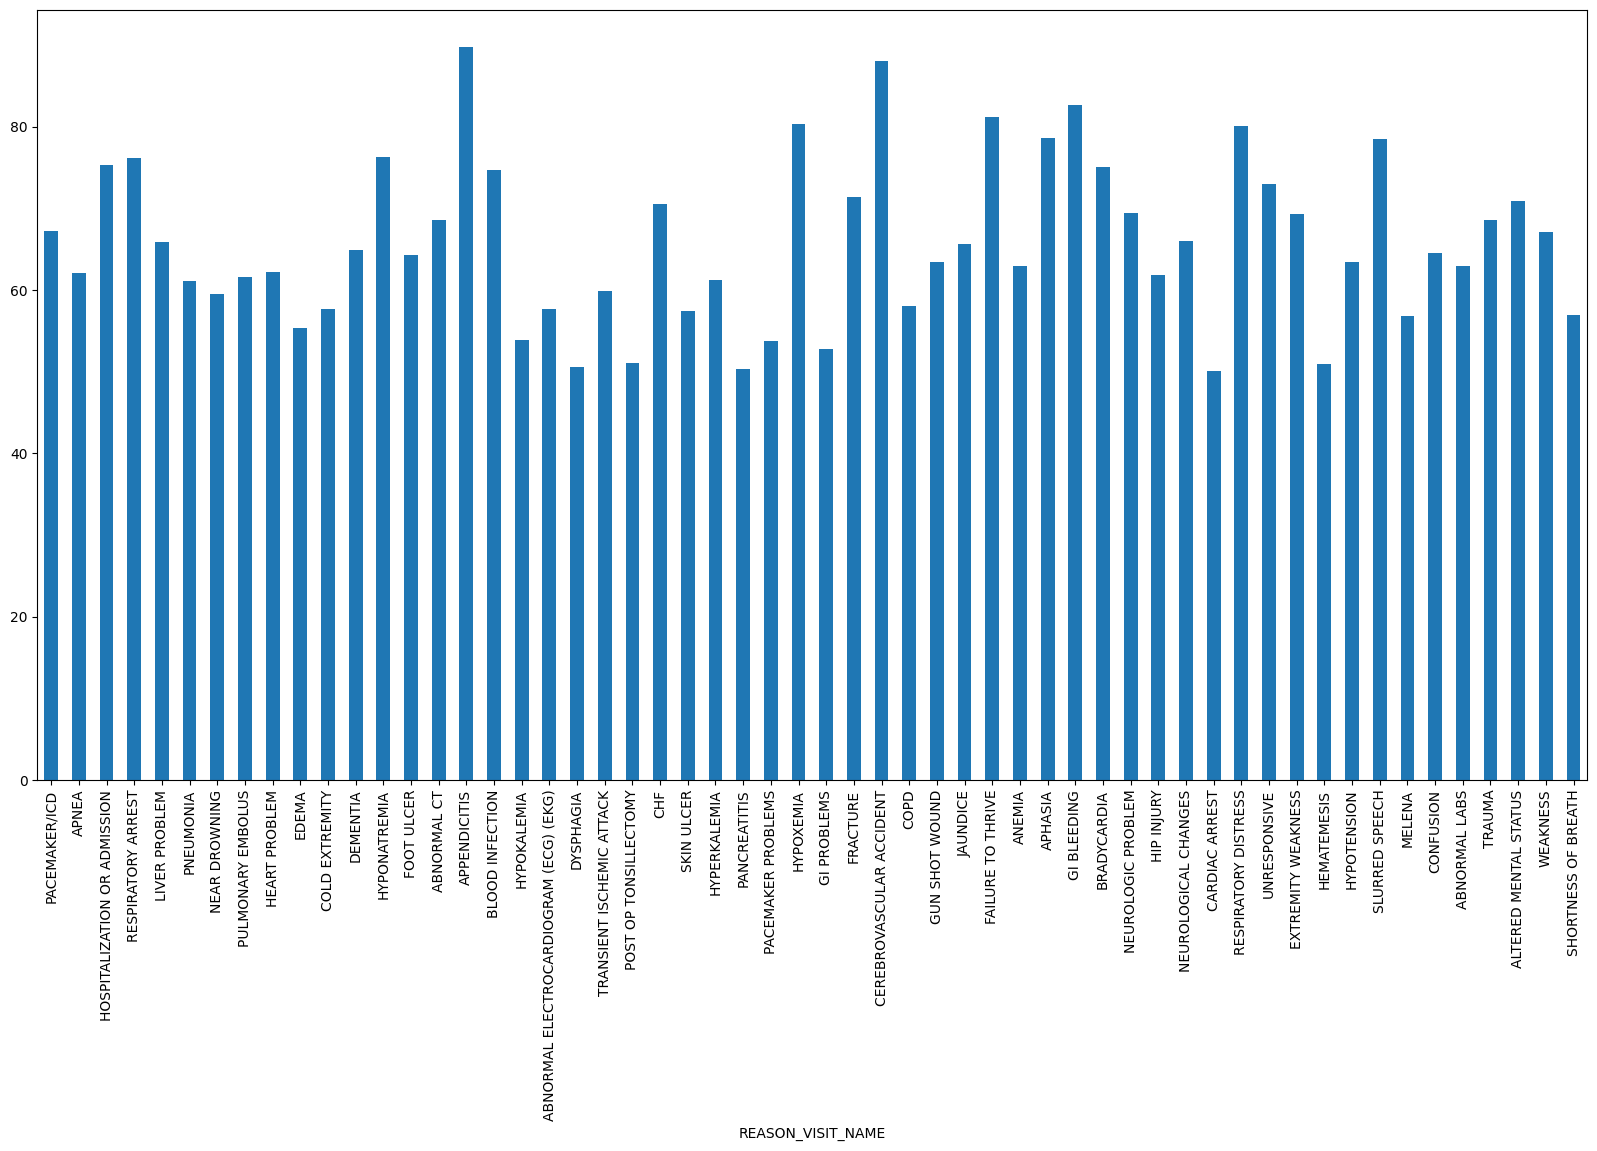

In [351]:
COVID_df['percentage_of_admittance'].plot(kind='bar', figsize=(20,10))

### Date/Time analysis

<Axes: xlabel='Year'>

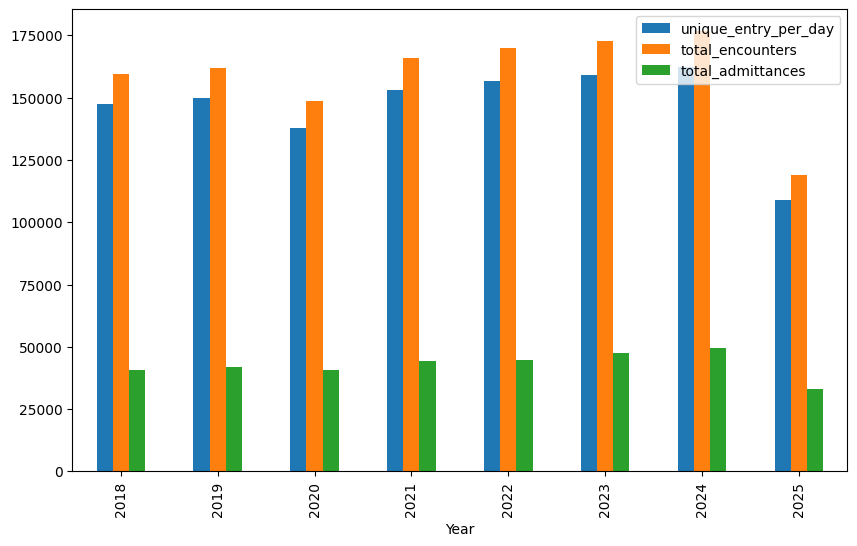

In [352]:
grouped_by_year = df.groupby(by = df['Date'].dt.year).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_year.plot(kind='bar', figsize=(10,6), xlabel='Year')

In [353]:
# Check what happend in Covid peak
df[(df['Date'].dt.year == 2020) & (df['Date'].dt.month >= 3) & (df['Date'].dt.month <= 6)].groupby(by='REASON_VISIT_NAME').agg('size').sort_values(ascending=False)

REASON_VISIT_NAME
ABDOMINAL PAIN              3490
CHEST PAIN                  2524
SHORTNESS OF BREATH         1667
FALL                        1539
FEVER                       1222
                            ... 
TRACHEOSTOMY TUBE CHANGE       1
ABNORMAL EEG                   1
WORD FINDING PROBLEMS          1
WOUND VAC PLACEMENT            1
ABNORMAL G TUBE                1
Length: 530, dtype: int64

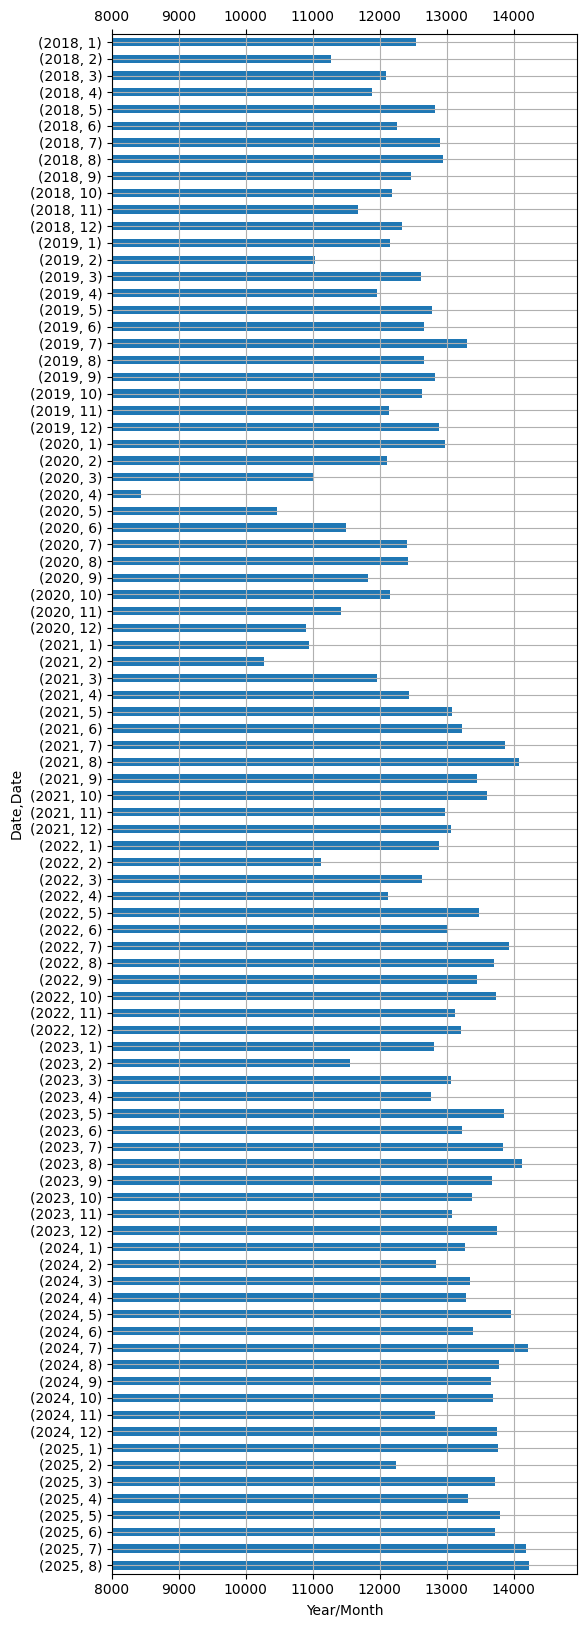

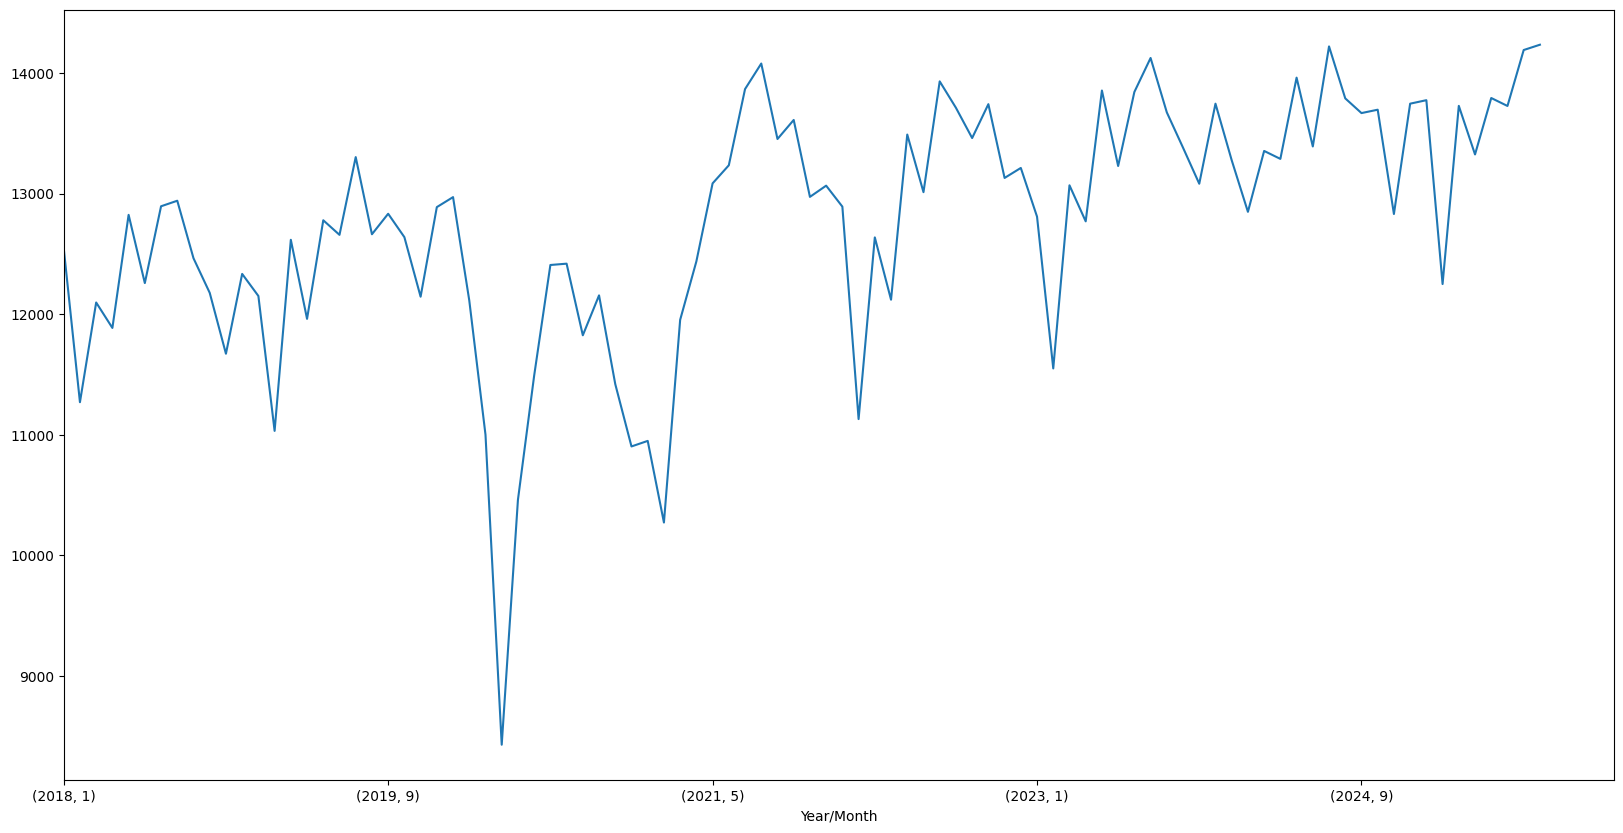

In [354]:
grouped_by_year_month = df.groupby(by = [df['Date'].dt.year, df['Date'].dt.month]).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
# for i in range(2018,2026):
#     grouped_by_year.loc[i].plot.bar()

ax1 = grouped_by_year_month['unique_entry_per_day'].plot(kind='barh', figsize = (6,20), xlabel='Year/Month', xlim=8000, grid=True)
ax1.invert_yaxis()
ax1.tick_params(top=True, labeltop=True)
plt.show()
ax2 = grouped_by_year_month['unique_entry_per_day'].plot(kind='line', figsize = (20,10), xlabel='Year/Month', xlim=0)
plt.show()



<Axes: xlabel='Month'>

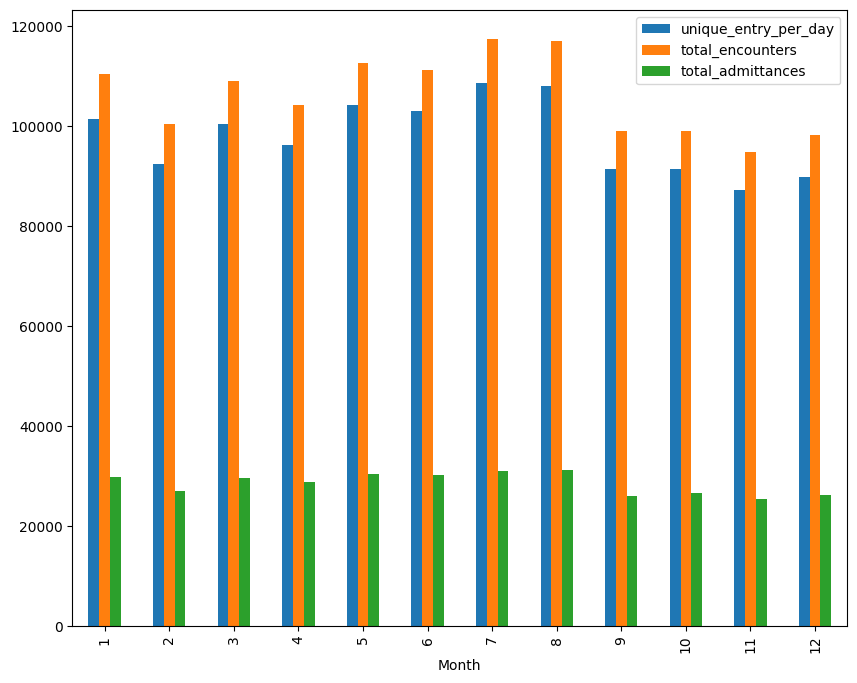

In [355]:
grouped_by_month = df.groupby(by = df['Date'].dt.month).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_month.plot(kind='bar', figsize = (10,8), xlabel='Month')

<Axes: xlabel='Day of the month'>

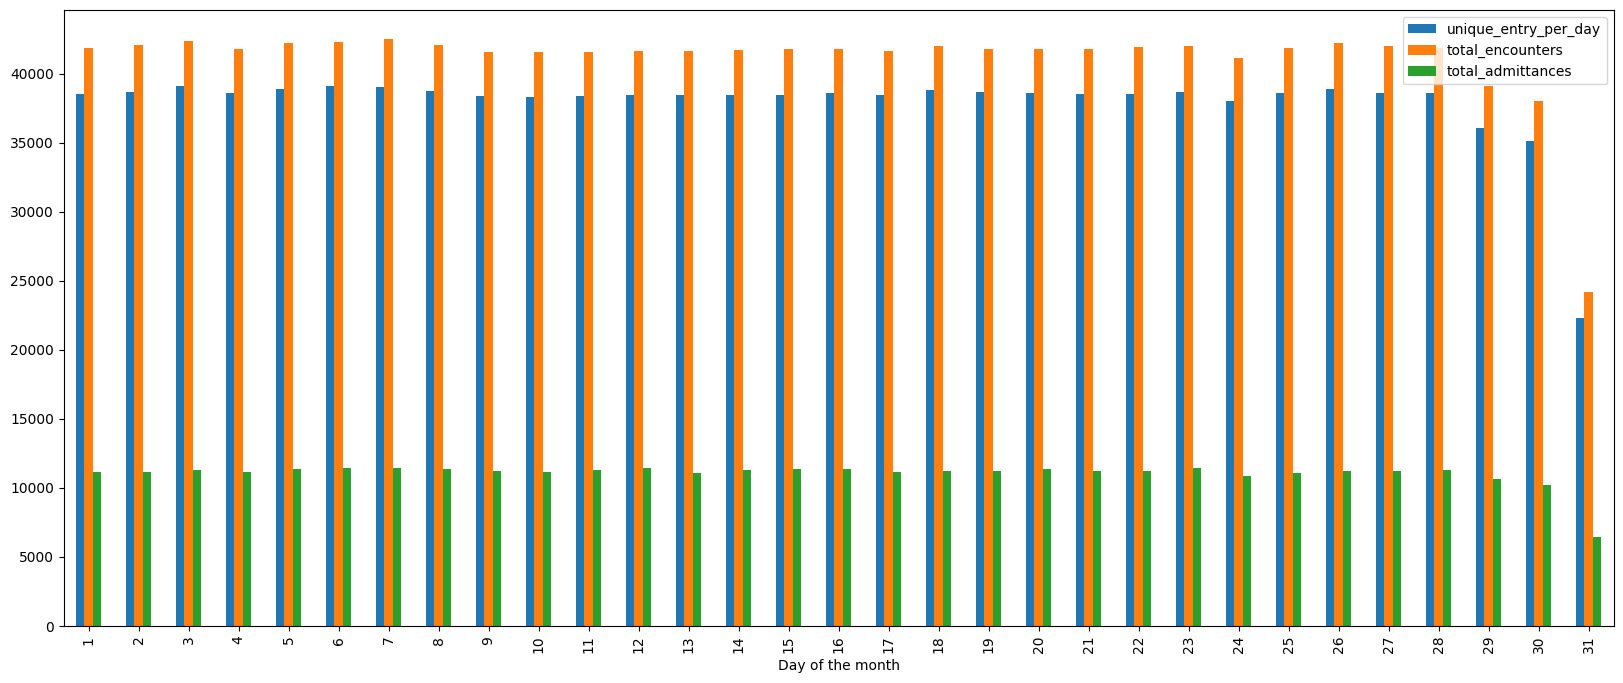

In [356]:
grouped_by_day = df.groupby(by = df['Date'].dt.day).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_day.plot(kind='bar', figsize = (20,8), xlabel='Day of the month')

<Axes: xlabel='Day of the week'>

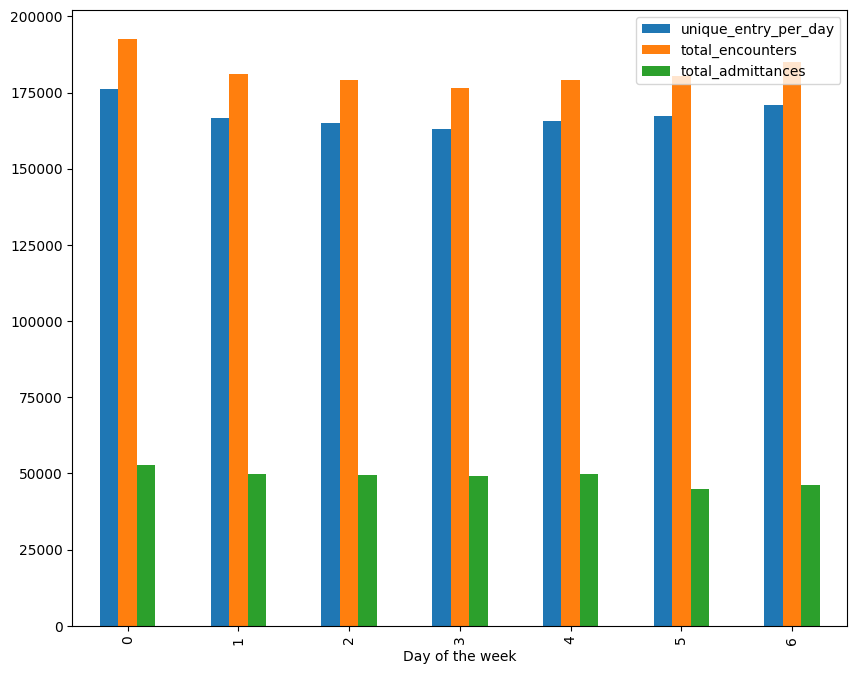

In [357]:
grouped_by_day_of_week = df.groupby(by = df['Date'].dt.day_of_week).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_day_of_week.plot(kind='bar', figsize = (10,8), xlabel='Day of the week')

In [358]:
grouped_by_year_reasons = df.groupby(by = [df['Date'].dt.year, df['REASON_VISIT_NAME']]).agg('size')
grouped_by_year_reasons = grouped_by_year_reasons.reset_index()
display(grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500)],
        grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500) & (grouped_by_year_reasons['REASON_VISIT_NAME']=='ALLERGIC REACTION')]
)

,Date,REASON_VISIT_NAME,0
4,2018,ABDOMINAL PAIN,12184
18,2018,ALCOHOL INTOXICATION,1625
20,2018,ALLERGIC REACTION,799
23,2018,ALTERED MENTAL STATUS,1063
34,2018,ANKLE INJURY,879
...,...,...,...
5169,2025,VAGINAL BLEEDING,918
5181,2025,VOMITING,2701
5183,2025,WEAKNESS,1895
5189,2025,WITHDRAWAL,536


,Date,REASON_VISIT_NAME,0
20,2018,ALLERGIC REACTION,799
692,2019,ALLERGIC REACTION,902
1352,2020,ALLERGIC REACTION,665
1996,2021,ALLERGIC REACTION,905
2659,2022,ALLERGIC REACTION,889
3339,2023,ALLERGIC REACTION,969
3996,2024,ALLERGIC REACTION,1072
4634,2025,ALLERGIC REACTION,700


Since there is no much insight in direct date analysis, lets try to see if there are any "seasonal illnesses"

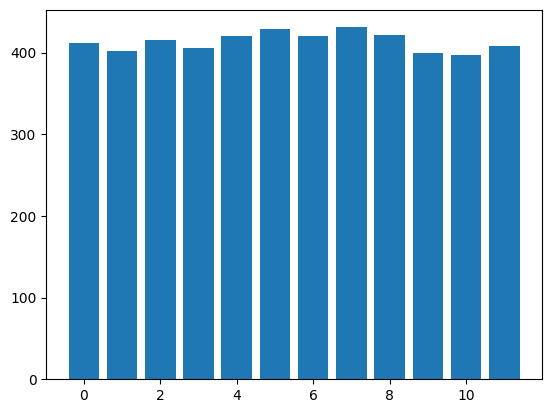

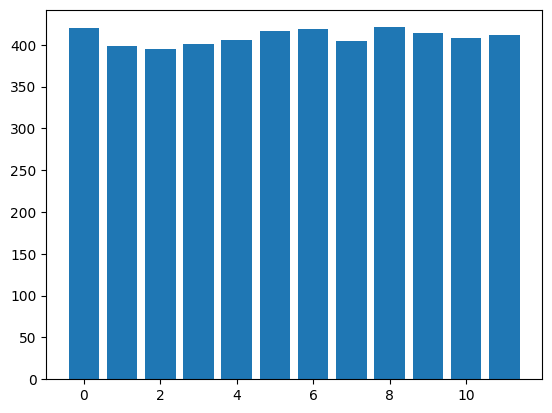

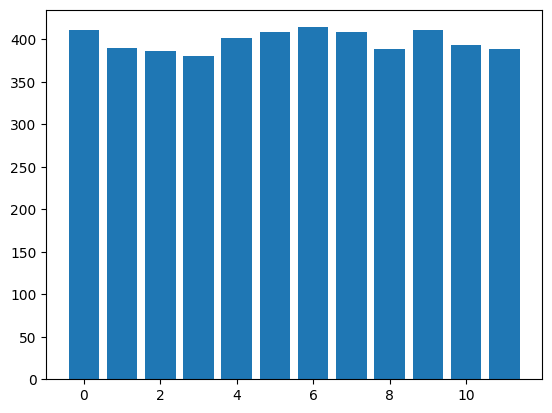

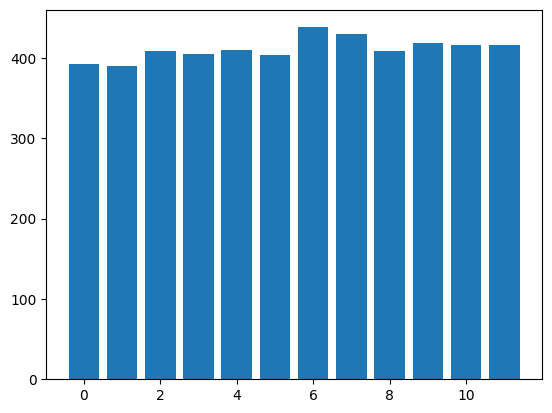

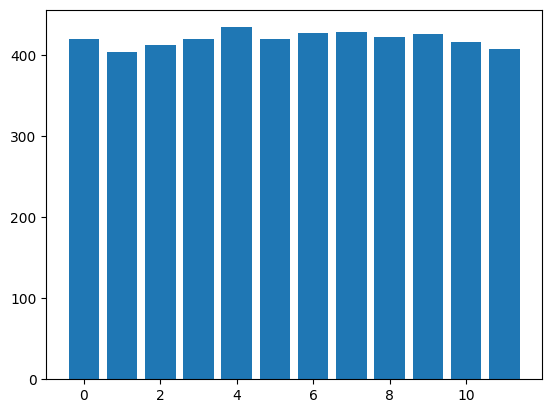

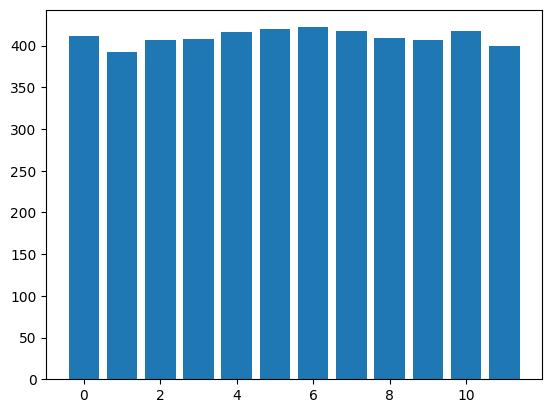

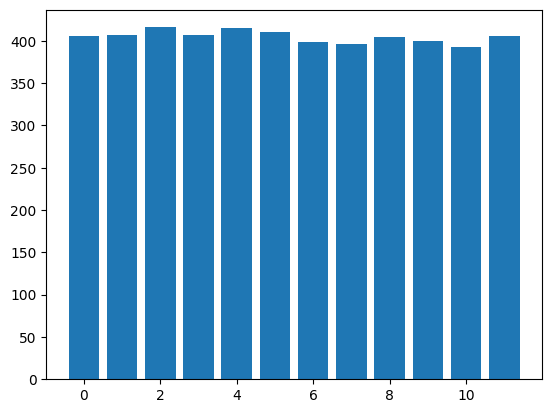

In [359]:
for j in range(2018, 2025):
    test = df[df['Date'].dt.year==j].groupby(by=[df['Date'].dt.month, df['REASON_VISIT_NAME']])['REASON_VISIT_NAME'].apply('size').to_frame()
    count_of_reasons_per_month =  [test.loc[(i)].shape[0] for i in range(1,13)]
    plt.bar(range(len(count_of_reasons_per_month)),count_of_reasons_per_month)
    plt.show()

In [360]:
test = df[df['Date'].dt.year==2022].groupby(by=[df['Date'].dt.month, df['REASON_VISIT_NAME']])['REASON_VISIT_NAME'].apply('size').to_frame()
test2 = test.rename(columns={'REASON_VISIT_NAME':'count_of_reason'}).reset_index()
test2[test2['count_of_reason']>500]

,Date,REASON_VISIT_NAME,count_of_reason
3,1,ABDOMINAL PAIN,1014
75,1,CHEST PAIN,788
343,1,SHORTNESS OF BREATH,537
421,2,ABDOMINAL PAIN,952
487,2,CHEST PAIN,698
825,3,ABDOMINAL PAIN,1084
892,3,CHEST PAIN,729
969,3,FALL,504
1238,4,ABDOMINAL PAIN,973
1310,4,CHEST PAIN,752


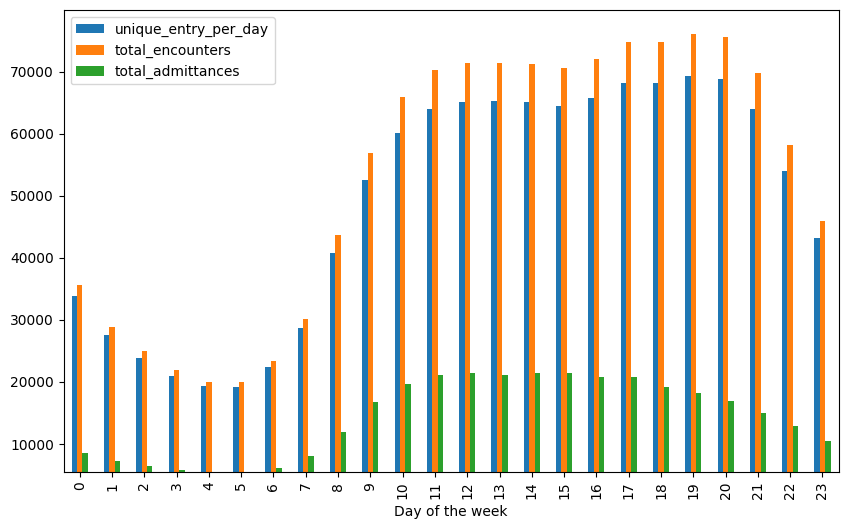

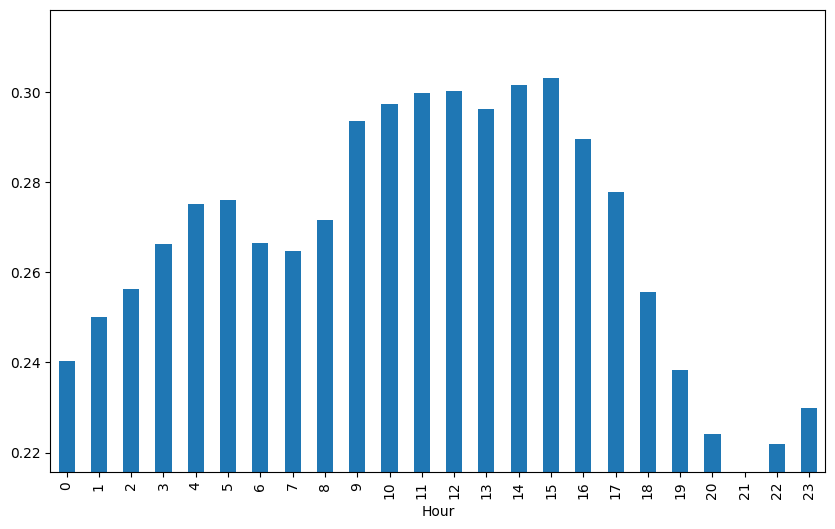

In [361]:
grouped_by_time = df.groupby(by = df['Hour']).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_time['admitance_rate'] = grouped_by_time['total_admittances'] / grouped_by_time['total_encounters']
grouped_by_time.iloc[:,:-1].plot(kind='bar', figsize = (10,6), xlabel='Day of the week', ylim=grouped_by_time.iloc[:,:-1].min()['total_admittances'])
plt.show()
grouped_by_time['admitance_rate'].plot(kind='bar', figsize = (10,6), ylim=grouped_by_time['admitance_rate'].min())
plt.show()


### Analysis by site

,site,total_encounters,total_admittances,admittance_rate
Site,,,,
A,308478,339622,107210,0.315674
B,423139,463877,118092,0.254576
C,250370,267847,81899,0.305768
D,192323,202365,35136,0.173627


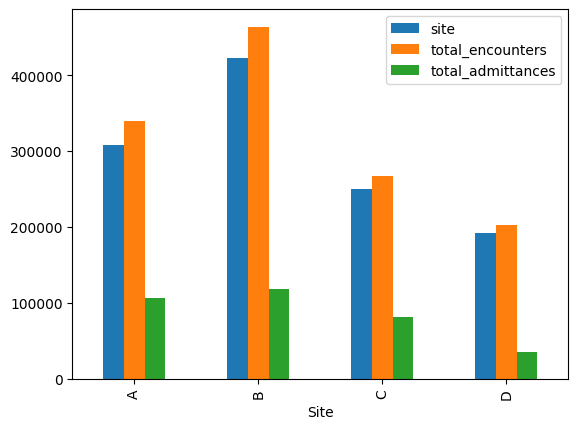

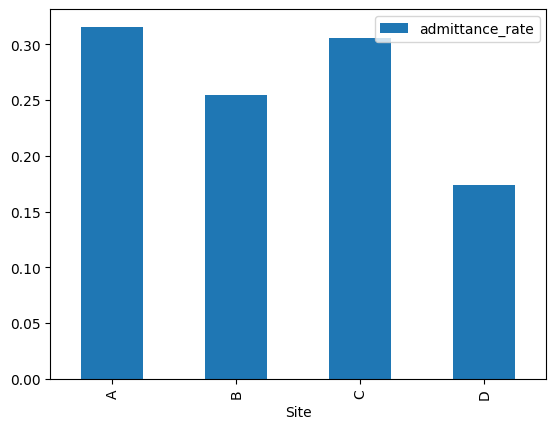

In [362]:
grouped_by_site = df.groupby(by='Site').agg(
    site = ('Site', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_site['admittance_rate'] = grouped_by_site['total_admittances'] /grouped_by_site['total_encounters']
display(grouped_by_site)
grouped_by_site.iloc[:,:-1].plot(kind='bar') # finally some sort of imbalance
plt.show()

grouped_by_site['admittance_rate'].plot(kind='bar', legend=True)
plt.show()

### Misc

Why would 'ED Enc' and 'ED Enc Admitted' take values > 1 ?

In [10]:
df[df['ED Enc']>1].shape[0] / df.shape[0] # only 7%

0.07344312830513237

In [11]:
df[df['ED Enc Admitted']>1].shape[0] / df.shape[0]

0.00950856247498531